# Air Quality Data Science Project

Group Members:

Tuana Ceren Soylu 2230765039

Semanur Teke 2230765003

Sude Gündüz 2240765020

Theme: Environmental Data

Dataset: city_day.csv / Air Quality Data in India (2015 - 2020)

1. Introduction and Project Goal
As a group, we worked on the "Environmental Data" theme for our project. We decided to analyze the air quality in different Indian cities between 2015 and 2020.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FILE_ID = '1KIlS0dikidME8bUkvb1V3395VUKZtkfc'

csv_path = f'https://drive.google.com/uc?id={FILE_ID}'


## Step 1 — Data Collection

We use an existing dataset: **city_day.csv**, which contains daily air quality measurements per city.

In this part, we started by loading our dataset to see its general structure and size. Our main goal was to check the quality of our data and identify which pollutants have missing values. Understanding these gaps early on is very important for us because it helps us decide how to clean the data in the next steps before we start our analysis.

In [ ]:
df_raw = pd.read_csv(csv_path)
print("Shape:", df_raw.shape)
display(df_raw.head())


Shape: (29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
display(df_raw.info())

missing = df_raw.isna().mean().sort_values(ascending=False)
display(pd.DataFrame({"missing_rate": missing, "missing_count": df_raw.isna().sum()}))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


None

,missing_rate,missing_count
AQI,0.158511,4681
AQI_Bucket,0.158511,4681
Benzene,0.190410,5623
CO,0.069723,2059
City,0.000000,0
Date,0.000000,0
NH3,0.349734,10328
NO,0.121296,3582
NO2,0.121398,3585
NOx,0.141715,4185


From our first look at the data, we observed that we have a large enough dataset, but there are significant gaps that we need to address. Specifically, we found that pollutants like Xylene are missing in over 60% of the rows, and PM10 is missing in nearly 38%. We also noticed that the early records from 2015 have many empty values, likely because not all sensors were active at that time. Most importantly, our target variable is missing in about 15% of the data. This tells us that our next step must focus heavily on cleaning and handling these missing values to make the dataset reliable for our classification models.

## Step 2 — Data Preprocessing and Cleaning

### Plan
In this step, our main goal was to fix the messy parts of our data and make it ready for our models. First, we extracted time information year, month, and day from the Date column. We then filled all the empty spots in our dataset: we used the median for numbers and the most frequent value for categories.

Crucially, we decided to remove the numeric AQI column from our features because it would make the prediction too easy (data leakage). By the end of this step, we had a clean and organized dataset ready for analysis.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = df_raw.copy()

# 1) Date parse
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Target (label) remove the missing date
df = df.dropna(subset=["Date", "AQI_Bucket"]).reset_index(drop=True)

# 2) Times features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

# 3) Target and feature choice
target_col = "AQI_Bucket"
exclude = {"Date", "AQI", target_col}
feature_cols = [c for c in df.columns if c not in exclude]

features = df[feature_cols].copy()
target = df[target_col].copy()

# 4) type seperation
numeric_cols = features.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in features.columns if c not in numeric_cols]

# 5) imputation
# we used median
for c in numeric_cols:
    features[c] = features[c].fillna(features[c].median())

# categorical, most freq data mod
for c in categorical_cols:
    mode_val = features[c].mode(dropna=True)
    mode_val = mode_val.iloc[0] if len(mode_val) > 0 else "Unknown"
    features[c] = features[c].fillna(mode_val)

print("Final feature matrix shape:", features.shape)
print("Number of features:", features.shape[1])
print("Target classes:", target.nunique())
display(target.value_counts())


Final feature matrix shape: (24850, 17)
Number of features: 17
Target classes: 6


,count
AQI_Bucket,
Moderate,8829
Satisfactory,8224
Poor,2781
Very Poor,2337
Good,1341
Severe,1338


##Observations After Preprocessing

After cleaning the data, our final dataset has 24,850 rows and 17 features. We observed that the target variable, AQI_Bucket, is divided into 6 different classes.

Looking at the numbers, there is a clear "class imbalance" in our data. Most of our records fall into the Moderate (8,829) and Satisfactory (8,224) categories. On the other hand, the extreme cases like Good and Severe have much fewer examples. This is an important finding because it means our model will have a lot of data for moderate air quality, but might find it harder to learn the characteristics of very clean or very polluted air.

## Step 3 — Data Exploration and Analysis (EDA + Clustering)

We will:
- Report basic statistics
- Visualize distributions and correlations among pollutants
- Perform clustering on standardized numeric features (pollutants + time features).  
  We will compare K-Means, Agglomerative (hierarchical), and DBSCAN.

Clustering is **unsupervised**; it ignores `AQI_Bucket` and tries to discover structure in the feature space.

,count,mean,std,min,25%,50%,75%,max
PM2.5,24172.0,67.476613,63.075398,0.04,29.0000,48.785,80.9250,914.94
PM10,17764.0,118.454435,89.487976,0.03,56.7775,96.180,150.1825,917.08
NO,24463.0,17.622421,22.421138,0.03,5.6600,9.910,20.0300,390.68
NO2,24459.0,28.978391,24.627054,0.01,11.9400,22.100,38.2400,362.21
NOx,22993.0,32.289012,30.712855,0.00,13.1100,23.680,40.1700,378.24
NH3,18314.0,23.848366,25.875981,0.01,8.9600,16.310,30.3600,352.89
CO,24405.0,2.345267,7.075208,0.00,0.5900,0.930,1.4800,175.81
SO2,24245.0,14.362933,17.428693,0.01,5.7300,9.220,15.1400,186.08
O3,24043.0,34.912885,21.724525,0.01,19.2500,31.250,46.0800,257.73
Benzene,21315.0,3.458668,16.036020,0.00,0.2300,1.290,3.3400,455.03


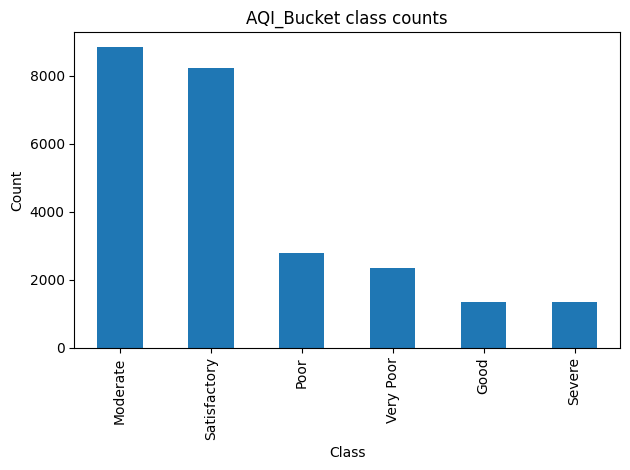

In [ ]:
# numeric_cols: numeric columns in df excluding AQI and the target (and Date)
exclude_numeric = {"AQI"}
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_numeric]

# 2) Basic descriptive stats for numeric columns
display(df[numeric_cols].describe().T)

# 3) Class balance plot
plt.figure()
df[target_col].value_counts().plot(kind="bar")
plt.title("AQI_Bucket class counts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

We noticed that different pollutants have very different ranges; for example, some have much higher values than others, which confirms why scaling our data is a necessary step.

Next, we created a bar chart to see the distribution of our target variable, AQI_Bucket. The plot clearly shows that our dataset is imbalanced. "Moderate" and "Satisfactory" are the most frequent categories, while "Good" and "Severe" have much fewer data points. This is an important observation for us because it means our future models might have a harder time correctly predicting these rarer categories.

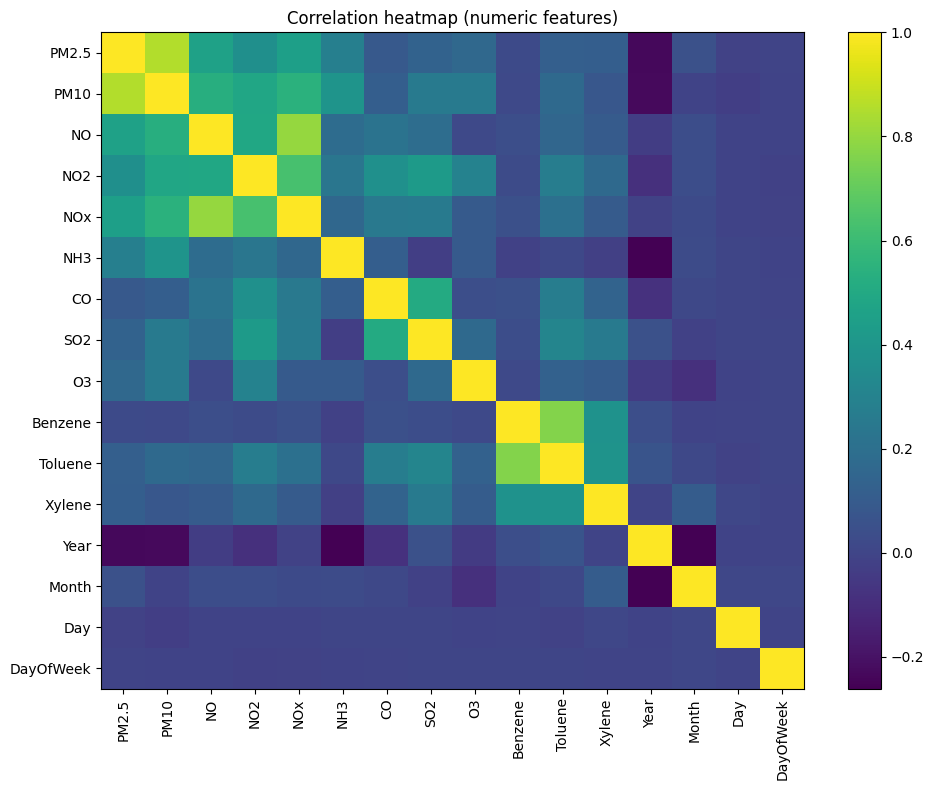

In [ ]:
# 4) Correlation heatmap for numeric features
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout()
plt.show()

We created a correlation heatmap to see how the different pollutants and time features relate to one each other. One of our main observations was the very strong positive correlation between nitrogen oxides NO, NO2, and NOx. This is expected because these gases usually come from the same sources, such as vehicle emissions. We also noticed a strong link between PM2.5 and PM10, which often move together in the atmosphere.These correlations are important for our project because they show us which features are redundant. Understanding these relationships helps us realize that certain pollutants provide similar information to our model, which is a key insight before we move on to the clustering and classification stages.

In [ ]:
# 5) Build clustering matrix using only numeric features (impute + scale)
X_num = df[numeric_cols].copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_num = imputer.fit_transform(X_num)
X_num = scaler.fit_transform(X_num)

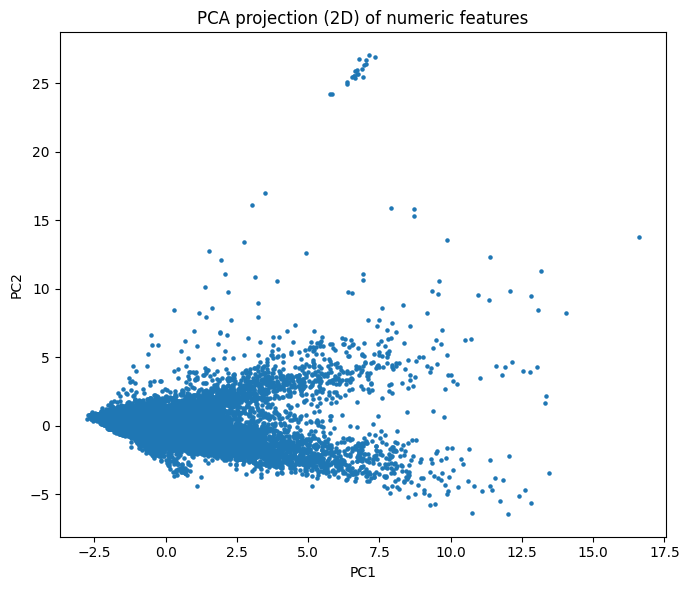

Explained variance ratio: [0.22285674 0.11687273] sum: 0.3397294706545302


In [ ]:
# 6) PCA for 2D visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_num)

plt.figure(figsize=(7, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=5)
plt.title("PCA projection (2D) of numeric features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_,
    "sum:",
    pca.explained_variance_ratio_.sum()
)


In this step, we used PCA to reduce our 17 different pollution features into just 2 dimensions so we could visualize them on a graph. When we look at the plot, we can see that the data points are very crowded and overlap a lot, without clear separations between groups.

Technically, these two dimensions explain only 34% of the total information. This tells us that our air quality data is very complex and high-dimensional. Since the pollution levels are so similar to each other, it shows us that classifying them will be a challenging but very important task for our models.

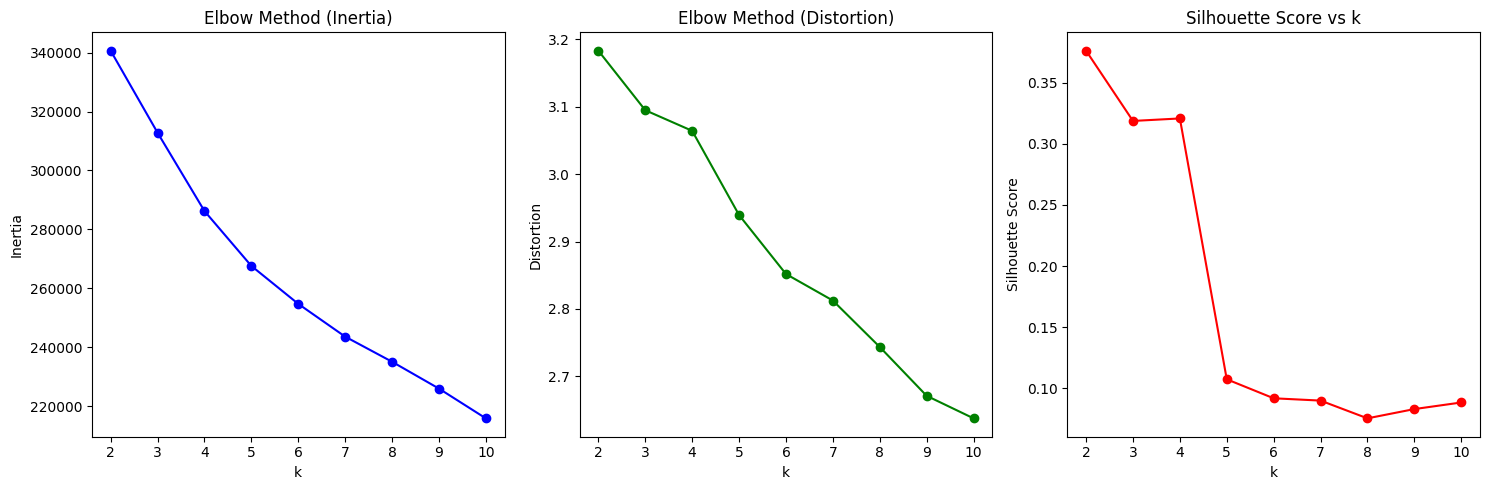

Best k according to the Sillhouette Score: 2


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import numpy as np

#7) Parameters
ks = range(2, 11)
inertias = []
distortions = []
sil_scores = []

# Model loop
for k in ks:
    # Define and fit the KMeans model
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_num)

    # 1. Inertia
    inertias.append(km.inertia_)

    # 2. Distortion
    distortion = sum(np.min(cdist(X_num, km.cluster_centers_, 'euclidean'), axis=1)) / X_num.shape[0]
    distortions.append(distortion)

    # 3. Silhouette Score
    sil_scores.append(silhouette_score(X_num, labels))

# --- VISUALIZATION ---

plt.figure(figsize=(15, 5))

# Plot 1: Elbow Method (Inertia)
plt.subplot(1, 3, 1)
plt.plot(ks, inertias, marker="o", color="blue")
plt.title("Elbow Method (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")

# Plot 2: Elbow Method (Distortion)
plt.subplot(1, 3, 2)
plt.plot(ks, distortions, marker="o", color="green")
plt.title("Elbow Method (Distortion)")
plt.xlabel("k")
plt.ylabel("Distortion")

# Plot 3: Silhouette Score
plt.subplot(1, 3, 3)
plt.plot(ks, sil_scores, marker="o", color="red")
plt.title("Silhouette Score vs k")
plt.xlabel("k")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

# Finding best k according to the Sillhouette Score
best_k = list(ks)[np.argmax(sil_scores)]
print(f"Best k according to the Sillhouette Score: {best_k}")

### Observations According to Plots:
The Elbow Method and Silhouette Score were used to determine the best number of clusters. From the inertia and distortion plots, a clear elbow appears at k = 4, where the decrease becomes slower. Although the Silhouette Score is highest at k = 2, the score at k = 4 is still reasonably high and provides better separation than larger values of k. Choosing k = 2 would result in too few clusters and an oversimplified structure, while higher values lead to lower silhouette scores and weaker clustering quality. Therefore, we selected k = 4 as the optimal number of clusters because it provides a good balance between cluster quality and model complexity.

In [ ]:
# 8) Train clustering models using the chosen k (KMeans + Agglomerative)
k = 4

kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
labels_km = kmeans.fit_predict(X_num)

agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
labels_agg = agg.fit_predict(X_num)

print("Silhouette (KMeans):", silhouette_score(X_num, labels_km))
print("Silhouette (Agglomerative):", silhouette_score(X_num, labels_agg))

Silhouette (KMeans): 0.320770464348089
Silhouette (Agglomerative): 0.18933660446773487


After selecting k = 4, we trained clustering models using both K-Means and Agglomerative Clustering. We computed Silhouette Score for each method to evaluate cluster quality. K-Means produced a higher silhouette score than Agglomerative Clustering, indicating better cluster separation for this dataset. Agglomerative Clustering, while still effective, showed slightly weaker separation between clusters.

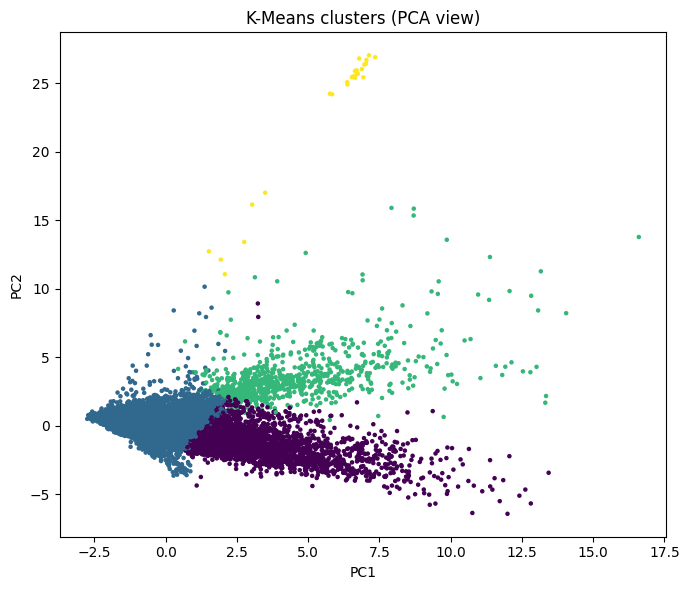

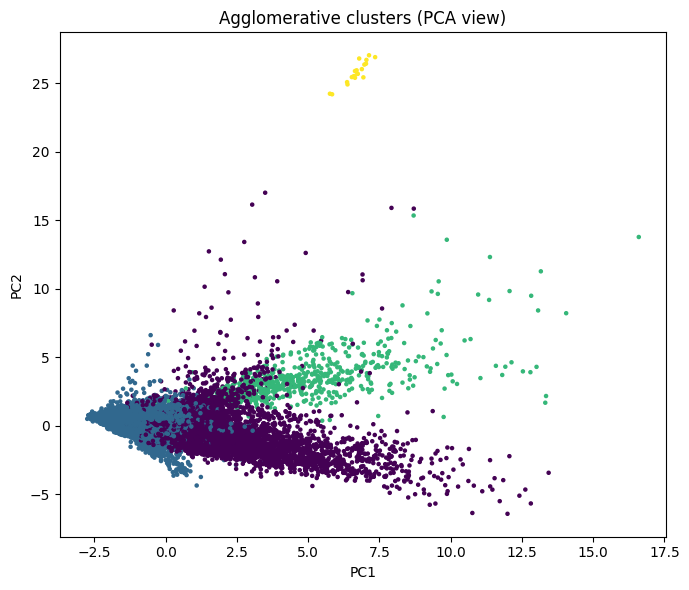

In [ ]:
# 9) Visualize clusters in PCA space
def plot_clusters(title, labels):
    plt.figure(figsize=(7, 6))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=5)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

plot_clusters("K-Means clusters (PCA view)", labels_km)
plot_clusters("Agglomerative clusters (PCA view)", labels_agg)


### Observations According to PCA Plots:
The PCA plots show how the clusters are separated in two dimensions. In the K-Means plot, clusters appear better separated, especially along the first principal component (PC1), with less overlap between groups. In contrast, in the the Agglomerative Clustering result the clusters overlap more, especially in the middle area, which makes the separation less clear.

These visual observations are consistent with the Silhouette Scores, where K-Means has a higher score than Agglomerative Clustering. Therefore, K-Means gives better clustering results for k = 4, both visually and numerically.

## Step 4 — Predictive Modelling (Classification)

The goal of this step is to predict the `AQI_Bucket` (categorical air quality label) using pollutant measurements together with city and time-related features.

We will:
1. Split data into **train / validation / test** with stratification.
2. Train **three different classifiers** :
   - Logistic Regression
   - Decision Tree
   - k-Nearest Neighbors (k-NN)
3. Compare performance on the validation set, select a model, then evaluate on the test set.

All models use the same preprocessing steps, which includes handling missing values, scaling numerical features, and one-hot encoding categorical features.

In [ ]:

# Defining features
target_col = "AQI_Bucket"

X = df.drop(columns=["AQI", target_col, "Date"], errors="ignore")
y = df[target_col]

# Train/Val/Test split (70/15/15) with stratification
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)



Train: (17395, 17) (17395,)
Val:   (3727, 17) (3727,)
Test:  (3728, 17) (3728,)


The dataset is split into training (70%), validation (15%), and test (15%) sets using stratified sampling.The training set is used to fit the models, the validation set is used for model selection, and the test set is used only for the final evaluation.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
import numpy as np

# 1) Separate numerical and categorical features
# IMPORTANT: The 'Date' column is handled separately.
cols_to_drop = ['Date']
X_train_clean = X_train.drop(columns=cols_to_drop, errors='ignore')
X_val_clean = X_val.drop(columns=cols_to_drop, errors='ignore')
X_test_clean = X_test.drop(columns=cols_to_drop, errors='ignore')

numeric_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train_clean.select_dtypes(include=["object"]).columns.tolist()

# 2) Fix data type issues
# Convert categorical columns to string to prevent imputer errors
X_train_cat_raw = X_train_clean[categorical_cols].astype(str)
X_val_cat_raw = X_val_clean[categorical_cols].astype(str)
X_test_cat_raw = X_test_clean[categorical_cols].astype(str)

# 3) Imputation
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train_num = num_imputer.fit_transform(X_train_clean[numeric_cols])
X_val_num   = num_imputer.transform(X_val_clean[numeric_cols])
X_test_num = num_imputer.transform(X_test_clean[numeric_cols])

X_train_cat_imp = cat_imputer.fit_transform(X_train_cat_raw)
X_val_cat_imp   = cat_imputer.transform(X_val_cat_raw)
X_test_cat_imp = cat_imputer.transform(X_test_cat_raw)

# 4) Encoding
# Use OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_cat_enc = encoder.fit_transform(X_train_cat_imp)
X_val_cat_enc   = encoder.transform(X_val_cat_imp)
X_test_cat_enc = encoder.transform(X_test_cat_imp)

# 5) Scaling (for numerical features)
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_val_num_scaled   = scaler.transform(X_val_num)
X_test_num_scaled = scaler.transform(X_test_num)

# 6) Combine numerical and categorical features
X_train_prep = np.hstack([X_train_num_scaled, X_train_cat_enc])
X_val_prep   = np.hstack([X_val_num_scaled, X_val_cat_enc])
X_test_prep = np.hstack([X_test_num_scaled, X_test_cat_enc])

print(f"Number of final features: {X_train_prep.shape[1]}")

Number of final features: 42


Before training the classification models, we applied several preprocessing steps to the data. Numerical and categorical features were handled separately, and missing values were imputed using the median for numerical variables and the most frequent value for categorical variables. Categorical features were then encoded using one-hot encoding, while numerical features were standardized.

We removed the Date feature from the main preprocessing step because directly applying one-hot encoding to date values would create a very large number of unnecessary features and add noise to the model. Instead, we focused on keeping meaningful numerical and categorical variables to ensure efficient and reliable model training.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

# Define the models to compare
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

results = []
fitted_models = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train_prep, y_train)
    preds = model.predict(X_val_prep)

    # Compute evaluation metrics
    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds, average="macro")

    results.append((name, acc, f1))
    fitted_models[name] = model


# Create a results table and sort by macro F1-score
res_df = (
    pd.DataFrame(results, columns=["model", "val_accuracy", "val_macro_f1"])
      .sort_values("val_macro_f1", ascending=False)
)
display(res_df)


# Select the best model based on validation performance
best_model_name = res_df.iloc[0]["model"]
print("Selected best model:", best_model_name)


,model,val_accuracy,val_macro_f1
0,LogisticRegression,0.767642,0.721224
2,DecisionTree,0.739737,0.706882
1,KNN,0.729273,0.685188


Selected best model: LogisticRegression


### Model Comparison and Evaluation:

Three classification models were trained and evaluated on the validation set: Logistic Regression, Decision Tree, and k-Nearest Neighbors (k-NN). We compared model performance using both accuracy and macro F1-score but F1-score were chosen as the main criterion because accuracy can be tricky fror imbalanced data. F1-score treats all classes equally and is more suitable for imbalanced class distributions such as air quality categories. Logistic Regression achieved the highest validation accuracy and macro F1-score and was selected as the best model.

- **Logistic Regression:** increased `max_iter` to ensure convergence for multinomial classification. It performs well when classes are reasonably separable and offers good balance across all AQI categories, which is reflected in its higher macro F1-score.

- **Decision Tree:** provides interpretability and captures non-linear relationships. However, it is prone to overfitting, which may explain its slightly lower validation performance compared to Logistic Regression.

- **k-NN:** uses distance-based classification. Its performance is sensitive to feature scaling and noise, and it may struggle in high-dimensional spaces, leading to lower accuracy and macro F1-score.

## Step 5 — Model Evaluation and Visualizations

Following the modeling phase, we evaluated our best-performing model on the test set, which consisted of data it had never encountered during training. We measured an overall Accuracy of 76.6%. However, given the class imbalance in our dataset, we primarily focused on the Macro F1-score, which we calculated as 0.718. Upon examining the classification report, we observed that our model achieved high performance particularly in the 'Moderate' (0.80 F1) and 'Satisfactory' (0.81 F1) categories. In contrast, for the 'Good' class, which had fewer samples, the Recall rate remained at 0.45, indicating that the model struggled to correctly identify instances belonging to this specific class. To visualize these class-specific performances and identify which categories were most frequently confused, we generated a Confusion Matrix to analyze the distribution of errors.

Test accuracy: 0.7666309012875536
Test macro F1: 0.7183706623776356

Classification report (test):
              precision    recall  f1-score   support

        Good       0.72      0.45      0.55       201
    Moderate       0.78      0.82      0.80      1325
        Poor       0.68      0.58      0.63       417
Satisfactory       0.77      0.84      0.81      1234
      Severe       0.84      0.74      0.79       201
   Very Poor       0.74      0.75      0.74       350

    accuracy                           0.77      3728
   macro avg       0.76      0.69      0.72      3728
weighted avg       0.76      0.77      0.76      3728



<Figure size 800x600 with 0 Axes>

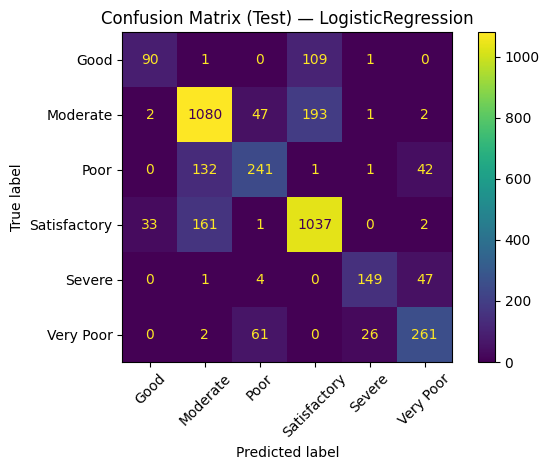

In [ ]:
# Test set evaluation
best_clf = fitted_models[best_model_name]
test_pred = best_clf.predict(X_test_prep)

test_acc = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred, average="macro")

print("Test accuracy:", test_acc)
print("Test macro F1:", test_f1)
print("\nClassification report (test):")
print(classification_report(y_test, test_pred))

# Confusion matrix
labels_sorted = sorted(y.unique())
cm = confusion_matrix(y_test, test_pred, labels=labels_sorted)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(xticks_rotation=45, values_format="d")
plt.title(f"Confusion Matrix (Test) — {best_model_name}")
plt.tight_layout()
plt.show()


To further assess the model's predictive power beyond simple label assignments, we analyzed its performance based on probability scores. We binarized the labels for each air quality category to perform a class-specific evaluation using ROC and Precision-Recall curves. The AUC values derived from the ROC curves allowed us to verify the model's capability to distinguish between different pollution levels. Additionally, the Precision-Recall curves provided deeper insights into the model's stability, especially for classes like 'Severe' and 'Satisfactory'. These visualizations mathematically and graphically demonstrated how our model handles the trade-off between precision and recall across various air quality thresholds.

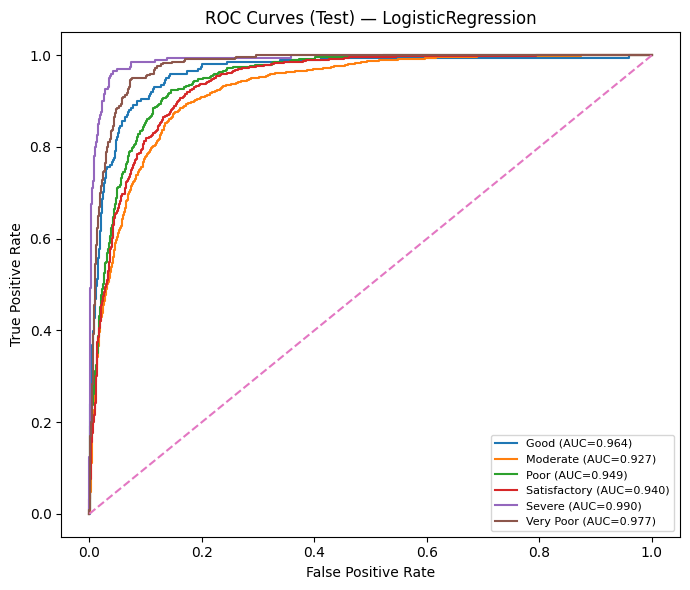

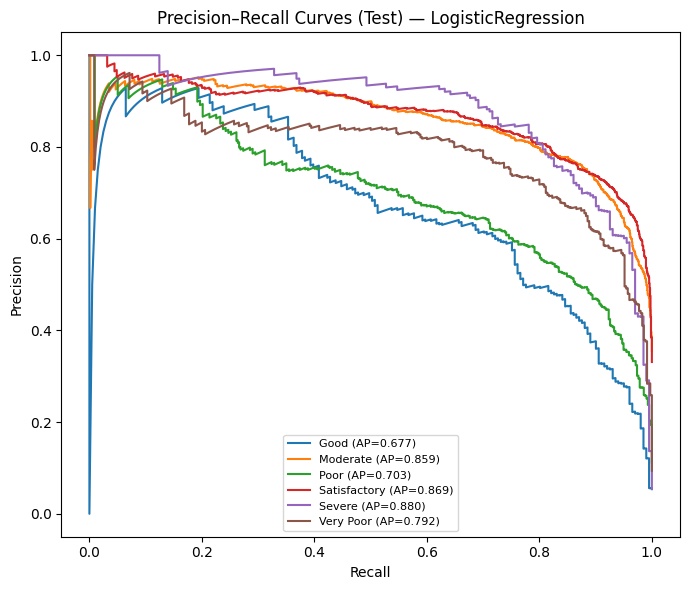

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Need probability scores
if hasattr(best_clf, "predict_proba"):
    y_score = best_clf.predict_proba(X_test_prep)
else:
    y_score = best_clf.decision_function(X_test_prep)

classes = labels_sorted
y_test_bin = label_binarize(y_test, classes=classes)

# ROC curves
plt.figure(figsize=(7, 6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"ROC Curves (Test) — {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Precision–Recall curves
plt.figure(figsize=(7, 6))
for i, cls in enumerate(classes):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
    plt.plot(rec, prec, label=f"{cls} (AP={ap:.3f})")

plt.title(f"Precision–Recall Curves (Test) — {best_model_name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## General Evaluation
In conclusion, our evaluation showed that the developed model is generally successful in predicting air quality levels in Indian cities. While the model demonstrated consistent and high performance for dominant classes like 'Moderate' and 'Satisfactory', we observed a decrease in performance for minority classes like 'Good' due to the inherent class imbalance. Overall, with an accuracy of 76.6% and a balanced Macro F1-score, we determined that our model provides reliable and meaningful predictions based on the environmental features analyzed throughout the project.